# 🚦 Traffic Sign Detection - ML Pipeline
GTSDB dataseti üzerinde YOLOv8 ile trafik işareti tespiti.

## Pipeline Adımları
1. Dataset Hazırlama
2. Model Eğitimi
3. Değerlendirme
4. Görselleştirme

## 1. Kurulum & Import

In [1]:
import sys, os
from pathlib import Path

# ML dizinini path'e ekle
ML_DIR = Path('../ml').resolve()
sys.path.insert(0, str(ML_DIR))

print(f'ML Directory: {ML_DIR}')
print(f'Dataset YAML: {ML_DIR / "dataset" / "data.yaml"}')
print(f'Weights Dir:  {ML_DIR / "weights"}')

ML Directory: /Users/emirnar/Desktop/CSE460-Final-Project/traffic-sign-detection-yolo/ml
Dataset YAML: /Users/emirnar/Desktop/CSE460-Final-Project/traffic-sign-detection-yolo/ml/dataset/data.yaml
Weights Dir:  /Users/emirnar/Desktop/CSE460-Final-Project/traffic-sign-detection-yolo/ml/weights


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Dataset Hazırlama
> ⚠️ Dataset zaten hazırlandıysa bu hücreyi atlayın.

In [3]:
# Dataset durumunu kontrol et
dataset_dir = ML_DIR / 'dataset'
for split in ['train', 'val', 'test']:
    img_count = len(list((dataset_dir / 'images' / split).glob('*.jpg')))
    lbl_count = len(list((dataset_dir / 'labels' / split).glob('*.txt')))
    print(f'{split:>5}: {img_count} images, {lbl_count} labels')

train: 630 images, 630 labels
  val: 180 images, 180 labels
 test: 90 images, 90 labels


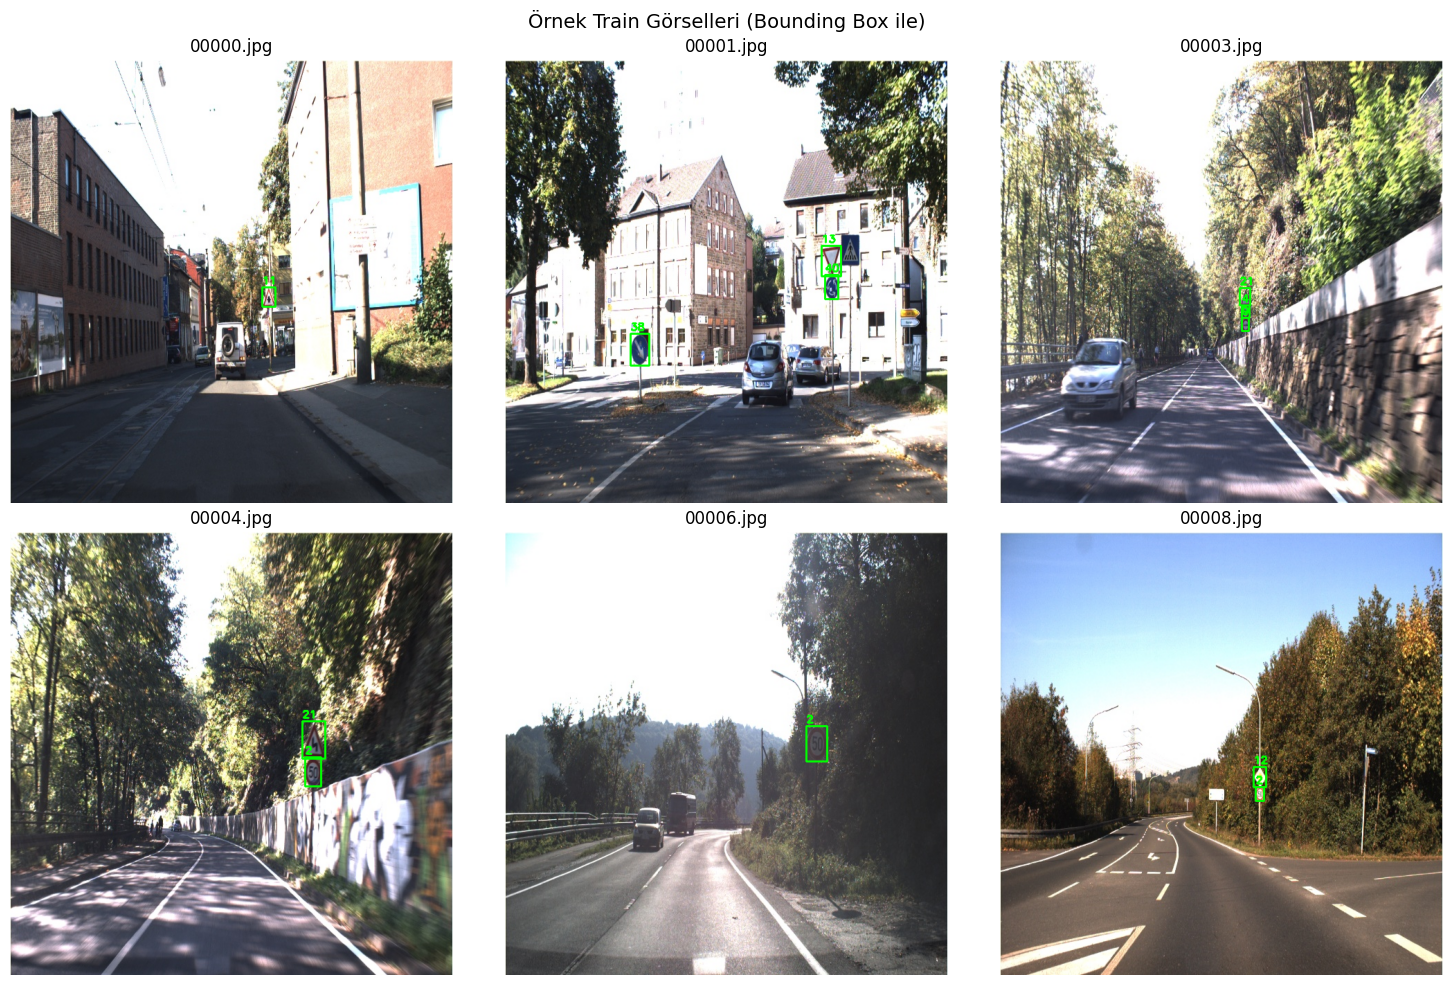

In [4]:
# Örnek görselleri görselleştir
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
train_imgs = sorted((dataset_dir / 'images' / 'train').glob('*.jpg'))[:6]

for ax, img_path in zip(axes.flat, train_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Label dosyasını oku ve bbox çiz
    lbl_path = dataset_dir / 'labels' / 'train' / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, xc, yc, w, h = int(parts[0]), *[float(x) for x in parts[1:]]
                    x1 = int((xc - w/2) * 640)
                    y1 = int((yc - h/2) * 640)
                    x2 = int((xc + w/2) * 640)
                    y2 = int((yc + h/2) * 640)
                    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
                    cv2.putText(img, str(cls), (x1,y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
    
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis('off')

plt.suptitle('Örnek Train Görselleri (Bounding Box ile)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Model Eğitimi (Training)
> Data augmentation dahil: horizontal flip, rotation, brightness/contrast

In [5]:
# YOLOv8 Pretrained model yükle
model = YOLO('yolov8n.pt')
print(f'Model: {model.model_name}')
print(f'Task: {model.task}')

Model: yolov8n.pt
Task: detect


In [ ]:
# Eğitimi başlat
DATASET_YAML = str(ML_DIR / 'dataset' / 'data.yaml')
RUNS_DIR = str(ML_DIR / 'runs')

results = model.train(
    data=DATASET_YAML,
    epochs=50,
    batch=16,
    imgsz=640,
    project=RUNS_DIR,
    name='gtsdb_detection',
    exist_ok=True,
    pretrained=True,

    # Data Augmentation
    fliplr=0.5,
    degrees=15.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    mosaic=1.0,
    mixup=0.1,

    # Hyperparameters
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
    weight_decay=0.0005,

    save=True,
    save_period=10,
    val=True,
    plots=True,
    verbose=True,
)

Ultralytics 8.4.46 🚀 Python-3.11.9 torch-2.11.0 CPU (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/emirnar/Desktop/CSE460-Final-Project/traffic-sign-detection-yolo/ml/dataset/data.yaml, degrees=15.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsdb_detection, nbs=64, nms=False, opset=None, optimize=Fa

## 4. Eğitim Sonuçları
> Eğitim tamamlandıktan sonra bu hücreleri çalıştırın.

In [ ]:
# Eğitim sonuç grafiklerini göster
results_dir = Path(RUNS_DIR) / 'gtsdb_detection'

result_images = ['results.png', 'confusion_matrix_normalized.png',
                 'F1_curve.png', 'PR_curve.png', 'labels.jpg']

for img_name in result_images:
    img_path = results_dir / img_name
    if img_path.exists():
        print(f'\n📊 {img_name}')
        display(Image(filename=str(img_path), width=800))
    else:
        print(f'⬜ {img_name} bulunamadı')

In [ ]:
# Loss ve metrik değerlerini CSV'den oku
import pandas as pd

csv_path = results_dir / 'results.csv'
if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print(df.tail(10))
else:
    print('results.csv bulunamadı - eğitim henüz tamamlanmadı')

## 5. Model Değerlendirme (Evaluation)

In [ ]:
# En iyi modeli yükle
import shutil

best_pt = Path(RUNS_DIR) / 'gtsdb_detection' / 'weights' / 'best.pt'
weights_dir = ML_DIR / 'weights'
weights_dir.mkdir(exist_ok=True)

if best_pt.exists():
    shutil.copy2(best_pt, weights_dir / 'best.pt')
    print(f'✅ best.pt kopyalandı: {weights_dir / "best.pt"}')
    best_model = YOLO(str(weights_dir / 'best.pt'))
else:
    print('❌ best.pt bulunamadı - eğitim tamamlanmadı')

In [ ]:
# Test seti üzerinde değerlendirme
metrics = best_model.val(
    data=DATASET_YAML,
    split='test',
    imgsz=640,
    verbose=True
)

print(f'\n📊 Test Sonuçları:')
print(f'  mAP50    : {metrics.box.map50:.4f}')
print(f'  mAP50-95 : {metrics.box.map:.4f}')
print(f'  Precision: {metrics.box.mp:.4f}')
print(f'  Recall   : {metrics.box.mr:.4f}')

## 6. Tahmin Görselleştirme

In [ ]:
# Test görselleri üzerinde tahmin yap ve görselleştir
test_imgs = sorted((dataset_dir / 'images' / 'test').glob('*.jpg'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, img_path in zip(axes.flat, test_imgs):
    results = best_model.predict(str(img_path), conf=0.25, verbose=False)
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(img_path.name)
    ax.axis('off')

plt.suptitle('Test Seti Tahminleri', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Tek görsel üzerinde detaylı tahmin
sample_img = str(test_imgs[0])
results = best_model.predict(sample_img, conf=0.25, verbose=False)

for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        bbox = box.xyxy[0].tolist()
        label = r.names[cls_id]
        print(f'  {label:>35s} | conf: {conf:.3f} | bbox: [{bbox[0]:.0f}, {bbox[1]:.0f}, {bbox[2]:.0f}, {bbox[3]:.0f}]')